In [1]:
import calendar
import warnings
from pathlib import Path
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import xarray as xr
from matplotlib import colormaps as cmaps
from numpy import double, int_
from numpy.typing import NDArray
from scipy.integrate import simpson
from scipy.optimize import OptimizeWarning, curve_fit
from scipy.signal import savgol_filter
from sympy import Piecewise, integrate, symbols
from tqdm import tqdm

In [2]:
FIG_SAVE_FMT = "png"

In [3]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
GEBCO_PATH = list(Path(DATA_DIR / "GEBCO/").glob("*.nc"))

In [4]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
bathymetry = xr.open_mfdataset(GEBCO_PATH)

In [5]:
def dt2cal(dt: NDArray[np.datetime64]) -> NDArray[np.uint32]:
    """Convert array of datetime64 to a calendar array.

    Args:
        dt (array of datetime64): datetimes to convert

    Returns:
        array: calendar array with last axis representing year, month, day, hour,
            minute, second, microsecond

    """
    # allocate output
    out = np.empty((*dt.shape, 7), dtype="u4")
    # decompose calendar floors
    Y, M, D, h, m, s = [dt.astype(f"M8[{x}]") for x in "YMDhms"]  # upper case okay here  # noqa: N806
    out[..., 0] = Y + 1970  # Gregorian Year
    out[..., 1] = (M - Y) + 1  # month
    out[..., 2] = (D - M) + 1  # date
    out[..., 3] = (dt - D).astype("m8[h]")  # hour
    out[..., 4] = (dt - h).astype("m8[m]")  # minute
    out[..., 5] = (dt - m).astype("m8[s]")  # second
    out[..., 6] = (dt - s).astype("m8[us]")  # microsecond
    return out


def find_nearest(
    array: NDArray[double | int_],
    value: double | int_ | float,
) -> int | None:
    """Find index of nearest value in array.

    Args:
        array (array): array to search
        value (scalar): value to find nearest to

    Returns:
        int or None: index of nearest value, or None if all values are NaN

    """
    if np.all(np.isnan(array)):
        return None
    array = np.asarray(array)
    idx = int(np.nanargmin(np.abs(array - value)))
    return idx


def haversine(
    lon1: float | np.ndarray | xr.DataArray,
    lat1: float | np.ndarray | xr.DataArray,
    lon2: float | np.ndarray | xr.DataArray,
    lat2: float | np.ndarray | xr.DataArray,
) -> float | np.ndarray | xr.DataArray:
    """Calculate the great circle distance between two points on the earth (specified in decimal degrees).

    Args:
        lon1 (scalar): longitude of first point
        lat1 (scalar): latitude of first point
        lon2 (scalar): longitude of second point
        lat2 (scalar): latitude of second point

    Returns:
        scalar: distance in km between (lon1, lat1) and (lon2, lat2)

    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km


def pycno(x: float | np.ndarray, zf: float, r: float, h: int = 125) -> float | np.ndarray:
    """Calculate idealized representation of the 25.8 kg/m^3 isopycnal.

    See also Austin and Barth, 2002.

    Args:
        x (scalar or array): cross-shelf distance in km
        zf (scalar): z intercept of the 25.8 kg/m^3 isopycnal in m
        r (scalar): radius of deformation in km
        h (int, optional): Offshore decay depth of the pycnocline. Defaults to 125.

    Returns:
        scalar or array: cross-shelf depth of the 25.8 kg/m^3 isopycnal

    """
    return -h + (zf + h) * np.exp(x / r)


def ws_integrand(tp: np.ndarray, t: int, tau: np.ndarray, k: float, rho: float = 1000) -> np.ndarray:
    """Integrand for computation of 8-day exponentially weighted integral of wind stress.

    See also Austin and Barth, 2002.

    Args:
        tp (array): integration variable, time
        t (scalar): upper limit of integration, time
        tau (array): wind stress array with same lenth as times tp
        k (scalar): relaxation timescale, same units as time
        rho (scalar, optional): Density of sea water. Defaults to 1000.

    Returns:
        array: integrand for use in scipy.integrate and computation of W8d

    """
    return tau[: t + 1] / rho * np.exp((tp[: t + 1] - t) / k)

## 2 Layer Model Computation

Computes the simple model for nearshore nitrate based on a piecewise function utilizing the Sympy library and then integrates over the depth to get a mean depth averaged nitrate predicted by the model.

In [6]:
bathymetry = xr.open_mfdataset(GEBCO_PATH)
bathymetry = bathymetry.isel({"lat": find_nearest(bathymetry["lat"].values, 44.66)})
bathymetry = bathymetry.interp({"lon": np.linspace(-130, -123, int(1e6))})
topo = bathymetry["elevation"].squeeze().values
coast = bathymetry.isel({"lon": np.argmin(np.abs(topo))})


bathymetry = bathymetry.interp({"lon": np.linspace(-130, -123, int(1e4))})
topo = bathymetry["elevation"].squeeze().values
long = bathymetry.lon.values
lat = bathymetry.lat.values

meters = np.nan * np.zeros(len(long))
for i, lo in enumerate(long):
    meters[i] = haversine(long[0], lat, lo, lat) - haversine(
        long[0],
        lat,
        coast.lon.values,
        lat,
    )

long = long[meters > -100]
topo = topo[meters > -100]
meters = meters[meters > -100]

delta = 0.1  # nitracline width in meters
step = 0.1
r = 43
h = 125
Nm = 35
zf = np.arange(-100, 100, 0.5)
x0 = meters[np.argmin(np.abs(long + 124.095))]
bot_depth = topo[np.argmin(np.abs(long + 124.095))]

mod_nit = np.nan * np.zeros((len(inner_nitrate.depth.values), len(zf)))
mod_nda = np.nan * np.zeros(len(zf))

z = symbols("z")
for i in tqdm(range(len(zf))):
    dn = pycno(x0, zf[i], r, h)
    n_profile = Piecewise(
        (0, z > dn),
        (Nm, z < dn),
    )
    mod_nit[:, i] = [n_profile.subs(z, val) for val in -inner_nitrate.depth.values]
    mod_nda[i] = integrate(n_profile, (z, bot_depth, 0)) / np.abs(bot_depth)

100%|██████████| 400/400 [00:06<00:00, 65.76it/s]


## NHL Fits

Determines the depth of the 25.8 $\sigma_\theta$ isopycnal as a function of cross-shelf distance for the gridded NHL data. Then fits NHL cross-shelf 25.8 $\sigma_\theta$ transects with a best fit exponential of the form $H - (Z_f-H)exp(-x/R_0)$. Also discards fits with unreasonably large R, H, or Zf.

In [7]:
# load NHL transects and compute distance from coastline in meters
nhl_grid = xr.load_dataset(
    "../data/NHL_Gridded/newport_hydrographic_line_gridded_sections.nc",
)
nhl_grid = nhl_grid.squeeze()
nhl_grid = nhl_grid.where(nhl_grid.pressure > 10)
nhl_grid["meters"] = -haversine(
    nhl_grid["longitude"],
    nhl_grid["latitude"],
    -124.0590,
    nhl_grid["latitude"],
)
print(f"Total number of NHL transects: {len(nhl_grid.time)}")
nhl_grid = nhl_grid.where(
    ((nhl_grid["time.month"] > 3) & (nhl_grid["time.month"] < 11)),
    drop=True,
)
print(f"Total number of summertime NHL transects: {len(nhl_grid.time)}")

# linearly interpolate to find 25.8 isopycnal depth
pycno_depth = np.nan * np.zeros((len(nhl_grid["meters"]), len(nhl_grid["time"])))
for i, _x in enumerate(tqdm(nhl_grid["meters"])):
    for j, _t in enumerate(nhl_grid["time"]):
        mask = ~np.isnan(nhl_grid["potential_density"][i, :, j])
        temp = nhl_grid["potential_density"][i, :, j][mask]
        if len(temp > 0):
            try:
                pycno_depth[i][j] = np.interp(
                    25.8,
                    nhl_grid["potential_density"][i, :, j][mask],
                    nhl_grid["pressure"][mask],
                )
                # pycno_depth[i][j] = inter
            except ValueError:
                pycno_depth[i][j] = np.nan
nhl_grid["pycno_depth"] = (["longitude", "time"], -pycno_depth)
nhl_grid = nhl_grid.where(nhl_grid.pycno_depth < -20)

# free H code
R = np.nan * np.zeros(len(pycno_depth.T))
R_err = np.nan * np.zeros(len(pycno_depth.T))
Zf = np.nan * np.zeros(len(pycno_depth.T))
Zf_err = np.nan * np.zeros(len(pycno_depth.T))
H = np.nan * np.zeros(len(pycno_depth.T))
H_err = np.nan * np.zeros(len(pycno_depth.T))

nhl_grid["meters"] = -haversine(
    nhl_grid["longitude"],
    nhl_grid["latitude"],
    -124.0590,
    nhl_grid["latitude"],
)

for i, d in enumerate(tqdm(-pycno_depth.T)):
    mask = ~np.isnan(d)
    if len(d[mask]) > 20:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", OptimizeWarning)
            (Zf[i], R[i], H[i]), cov = curve_fit(
                pycno,
                nhl_grid["meters"][mask],
                d[mask],
                p0=[0, 43, 125],
            )
            (Zf_err[i], R_err[i], H_err[i]) = np.sqrt(np.diagonal(cov))

nhl_grid["R"] = (["time"], R)
nhl_grid["Zf"] = (["time"], Zf)
nhl_grid["H"] = (["time"], H)
nhl_grid["Zf_err"] = (["time"], Zf_err)

nhl_grid = nhl_grid.resample(time="1D").median()
nhl_grid["meters"] = -haversine(
    nhl_grid["longitude"],
    nhl_grid["latitude"],
    -124.0590,
    nhl_grid["latitude"],
)


mask = (~np.isnan(nhl_grid.H)) & (~np.isnan(nhl_grid.R)) & (~np.isnan(nhl_grid.Zf))
mask = xr.DataArray(mask, dims=["time"], coords={"time": nhl_grid.time.values})
nhl_grid = nhl_grid.where(mask, drop=True)


fit_rmse = np.nan * np.empty(len(nhl_grid.time))
for i, t in enumerate(nhl_grid.time):
    temp = nhl_grid.sel(time=t)
    residuals = temp.pycno_depth - pycno(
        temp.meters.values,
        temp.Zf.values,
        temp.R.values,
        temp.H.values,
    )
    fit_rmse[i] = ((np.sum(residuals**2) / (residuals.size - 2)) ** 0.5).values

print(f"Total number of reasonable fits (fit_rmse < 10): {len(nhl_grid['time'].where(fit_rmse < 10))}")

Total number of NHL transects: 556
Total number of summertime NHL transects: 396


100%|██████████| 396/396 [00:11<00:00, 35.60it/s]


Total number of reasonable fits (fit_rmse < 10): 344


100%|██████████| 5/5 [00:21<00:00,  4.28s/it]


308

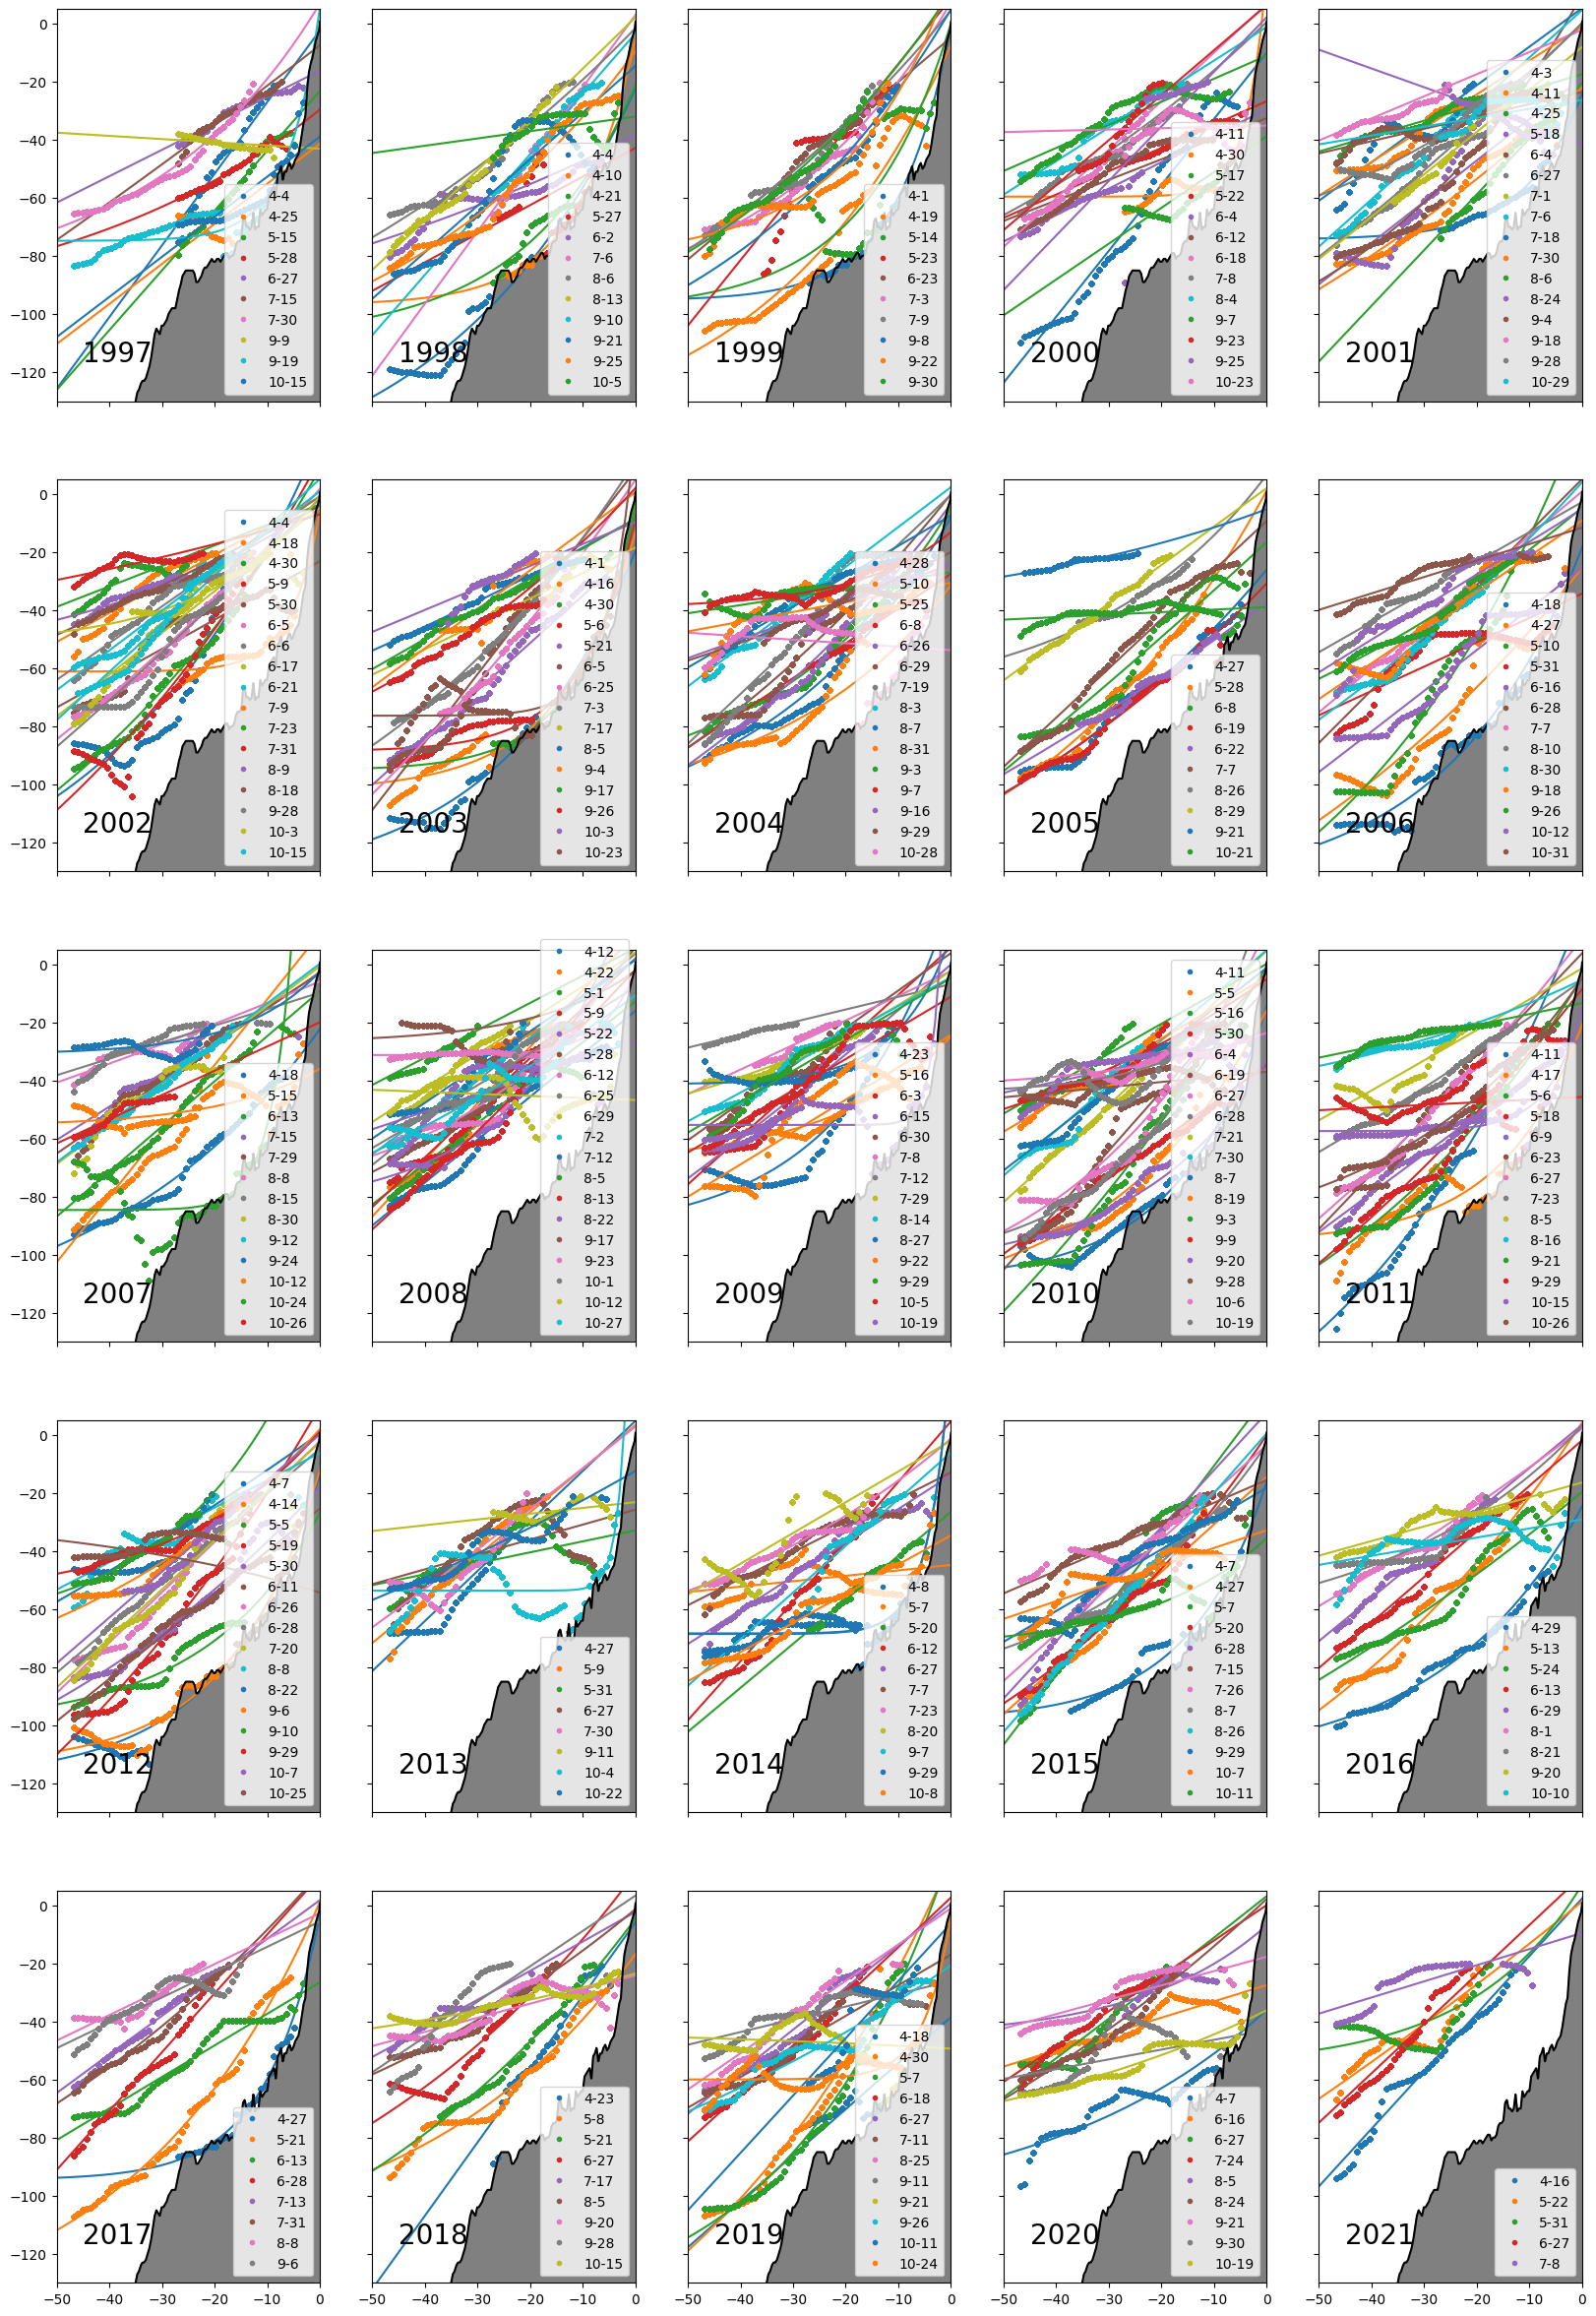

In [8]:
# plot transects and fits
col = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]
trange = np.arange(
    np.datetime64("1997"),
    np.datetime64("2022"),
    np.timedelta64(1, "Y"),
    dtype="datetime64[Y]",
)
tdelta = np.timedelta64(1, "Y")
rows = 5
cols = 5
N = 0
fig, axs = plt.subplots(5, 5, figsize=(20, 30), sharex=True, sharey=True)
for r in tqdm(range(rows)):
    for c in range(cols):
        mask = (nhl_grid["time"] >= trange[5 * r + c % 5]) & (nhl_grid["time"] < trange[5 * r + c % 5] + tdelta)
        for i, (t, d, Zf, R, H) in enumerate(
            zip(
                nhl_grid["time"][mask].values,
                nhl_grid["pycno_depth"][mask].values,
                nhl_grid["Zf"][mask].values,
                nhl_grid["R"][mask].values,
                nhl_grid["H"][mask].values,
                strict=False,
            ),
        ):
            mask = ~np.isnan(d) & (nhl_grid.meters.T[0] < -10)
            ymd = dt2cal(t)[0:3]
            if len(d[mask]) > 20:
                axs[r][c].plot(
                    nhl_grid["meters"],
                    d,
                    ".",
                    label=f"{ymd[1]}-{ymd[2]}",
                    c=col[i % len(col)],
                )
                axs[r][c].plot(
                    np.arange(-50, 5),
                    pycno(np.arange(-50, 5), Zf, R, H),
                    c=col[i % len(col)],
                )
                N += 1
        axs[r][c].annotate(ymd[0], xy=(0.1, 0.1), xycoords="axes fraction", fontsize=20)
        axs[r][c].fill_between(meters, -1000, topo, color="grey")
        axs[r][c].plot(meters, topo, color="black")
        handles, labels = axs[r][c].get_legend_handles_labels()
        by_label = dict(
            zip(labels, handles, strict=False),
        )  # dicts can't have duplicate keys, avoids duplicate legend entries
        axs[r][c].legend(by_label.values(), by_label.keys(), loc="lower right")
        axs[r][c].set_ylim([-130, 5])
        axs[r][c].set_xlim([-50, 0])
N

## Monthly mean NHL fits

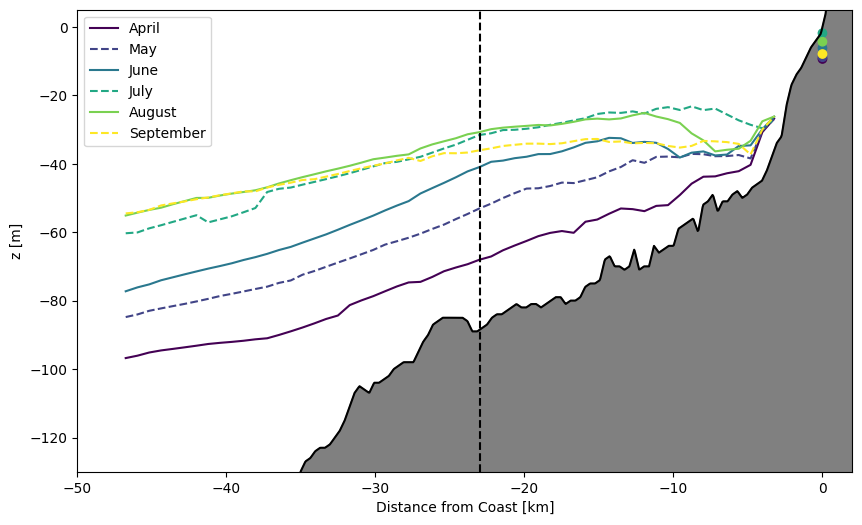

In [9]:
nhl_grid_monthly_mean = nhl_grid.groupby("time.month").mean()
nhl_grid_monthly_mean = cast("xr.Dataset", nhl_grid_monthly_mean)

nrows = 7
fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=True)

# For plotting months with colormap
colors = cmaps["viridis"](np.linspace(0, 1, 6))
linestyles = ["-", "--", "-", "--", "-", "--"]

for i in range(6):
    month = i + 4
    ax.plot(
        nhl_grid_monthly_mean["meters"].sel(month=month),
        nhl_grid_monthly_mean["pycno_depth"].sel(month=month),
        label=f"{calendar.month_name[month]}",
        color=colors[i],
        linestyle=linestyles[i],
    )

ax.fill_between(meters, -1000, topo, color="grey")
ax.plot(meters, topo, color="black")
ax.set_xlim(-50, 2)
ax.set_ylim(-130, 5)
ax.scatter(np.zeros(6), nhl_grid_monthly_mean["Zf"][:-1], c=colors)

plt.legend()

ax.set_ylabel("z [m]")
ax.set_xlabel("Distance from Coast [km]")

ax.vlines(-x0, ymin=-130, ymax=5, color="k", linestyle="--")
ax.vlines(-23, ymin=-130, ymax=5, color="k", linestyle="--")

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/nhl_monthly_mean_pycno_depth.{FIG_SAVE_FMT}",
    dpi=300,
    bbox_inches="tight",
)

## Zf, R, H Time Series

R median: 47.07
H median: 118.64


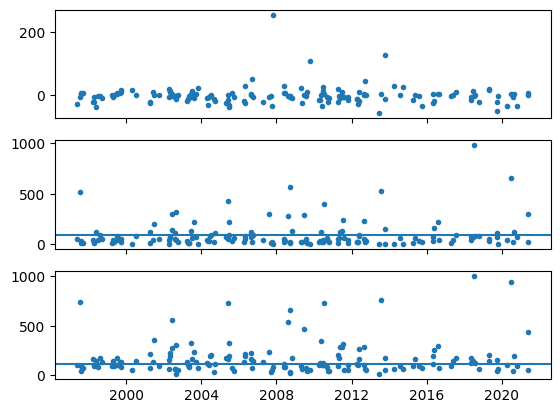

In [10]:
fig, axs = plt.subplots(3, 1, sharex=True)
mask = (
    (nhl_grid.Zf < 1000)
    & (nhl_grid.Zf > -1000)
    & (nhl_grid.R < 1000)
    & (nhl_grid.R > -1000)
    & (nhl_grid.H < 2000)
    & (fit_rmse < 10)
)
axs[0].plot(nhl_grid.time[mask], nhl_grid.Zf[mask], ".")
# axs[0].plot(nhl_grid.time, nhl_grid.Zf, '.')
# axs[0].set_ylim(-75, 125)
axs[1].plot(nhl_grid.time[mask], nhl_grid.R[mask], ".")
# axs[1].plot(nhl_grid.time, nhl_grid.R, '.')
# axs[1].set_ylim(-10, 200)
# axs[1].set_yscale('log')
axs[1].axhline(np.nanmean(nhl_grid.R[mask]))
# axs[1].axhline(np.nanmedian(nhl_grid.R))
axs[2].plot(nhl_grid.time[mask], nhl_grid.H[mask], ".")
# axs[2].plot(nhl_grid.time, nhl_grid.H, '.')
# axs[2].set_ylim(1, 2100)
# axs[2].set_yscale('log')
axs[2].axhline(np.nanmedian(nhl_grid.H[mask]))
# axs[2].axhline(np.nanmedian(nhl_grid.H))
print(f"R median: {np.nanmedian(nhl_grid.R[mask]):.2f}")
# print(f'R mean: {np.nanmedian(nhl_grid.R):.2f}')
print(f"H median: {np.nanmedian(nhl_grid.H[mask]):.2f}")
# print(f'H mean: {np.nanmedian(nhl_grid.H):.2f}')

## 25.8 Fit

Text(0.07, 0.63, '25.8 $\\sigma_{\\theta}$ Gridded\nTransect Data')

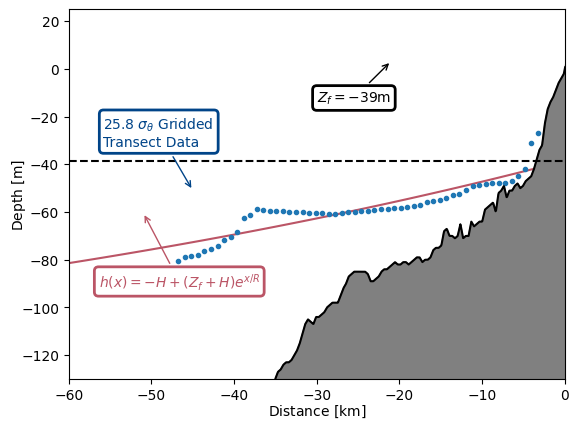

In [11]:
fig, axs = plt.subplots()
d = nhl_grid.isel(time=15)
mask = ~np.isnan(d)
axs.plot(d["meters"], d["pycno_depth"], ".")
axs.plot(
    np.arange(-60, 5),
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values),
    zorder=1,
    c="#BB5566",
)
axs.fill_between(meters, -1000, topo, color="grey")
axs.plot(meters, topo, color="black")
axs.set_ylim(-130, 25)
axs.set_xlim(-60, 0)
axs.set_xlabel("Distance [$\\mathsf{km}$]", labelpad=0)
axs.set_ylabel("Depth [$\\mathsf{m}$]", labelpad=-5)
bbox = {"boxstyle": "round", "fc": "w", "ec": "#BB5566", "lw": 2}
axs.annotate(
    "$h(x)=-H+(Z_f+H)e^{x/R}$",
    xy=(0.15, 0.45),
    xytext=(0.06, 0.25),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "#BB5566"},
    color="#BB5566",
)
axs.axhline(d.Zf, ls="--", color="k")
bbox = {"boxstyle": "round", "fc": "w", "ec": "k", "lw": 2}
axs.annotate(
    f"$Z_f={d.Zf.values:.0f} \\mathsf{{m}}$",
    xy=(0.65, 0.86),
    xytext=(0.5, 0.75),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "k"},
    color="k",
)
bbox = {"boxstyle": "round", "fc": "w", "ec": "#004488", "lw": 2}
axs.annotate(
    "25.8 $\\sigma_{\\theta}$ Gridded\nTransect Data",
    xy=(0.25, 0.51),
    xytext=(0.07, 0.63),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "#004488"},
    color="#004488",
)
# if savefigs:
#     plt.savefig("../../figs/pycno_fit.png", dpi=600)

## Zf-Wind Fit

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.448
Model:                            WLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     127.6
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           4.90e-22
Time:                        19:56:30   Log-Likelihood:                -594.24
No. Observations:                 159   AIC:                             1192.
Df Residuals:                     157   BIC:                             1199.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.2365      0.919    -14.397      0.000     -15.053     -11.421
x1          -294.0452     26.027    -11.298      0.000    -345.453    -242.638
==============================================================================
Omnibus:                        4.477   Durbin-Watson:                   1.643
Prob(Omnibus):                  0.107   Jarque-Bera (JB):                4.430
Skew:                          -0.407   Prob(JB):                        0.109
Kurtosis:                       2.932   Cond. No.                         34.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

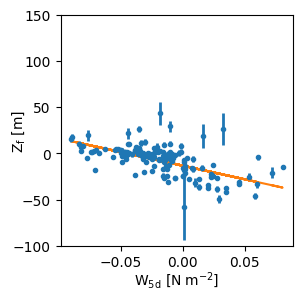

In [12]:
wind_use = "w5d"
wind_al_nhl, nhl_al_wind = xr.align(wind, nhl_grid)
m = dt2cal(nhl_al_wind["time"].values).T[1]
mask = ((m >= 4) & (m <= 9)) & (fit_rmse < 10)

wls_fit = sm.WLS(
    nhl_al_wind["Zf"][mask].values,
    sm.add_constant(wind_al_nhl[wind_use][mask].values),
    weights=1 / nhl_al_wind["Zf_err"][mask].values,
    missing="drop",
).fit()
fit = wls_fit.params[::-1]
r_squared = wls_fit.rsquared

fig, ax = plt.subplots(figsize=(3, 3))
ax.errorbar(
    wind_al_nhl[wind_use][mask],
    nhl_al_wind["Zf"][mask],
    nhl_al_wind["Zf_err"][mask],
    linestyle="",
    marker=".",
    elinewidth=2,
)
ax.plot(
    wind_al_nhl[wind_use][mask],
    wind_al_nhl[wind_use][mask] * fit[0] + fit[1],
    label=f"$\\beta_0$={fit[1]:.2f}\n$\\beta_1$={fit[0]:.2f}",
)
ax.set_ylim(-100, 150)
ax.set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{N \\; m^{-2}}$]", labelpad=0)
ax.set_ylabel("$\\mathsf{Z_f}$ [$\\mathsf{m}$]", labelpad=-10)
bbox = {"boxstyle": "round", "fc": "w"}
wls_fit.summary()

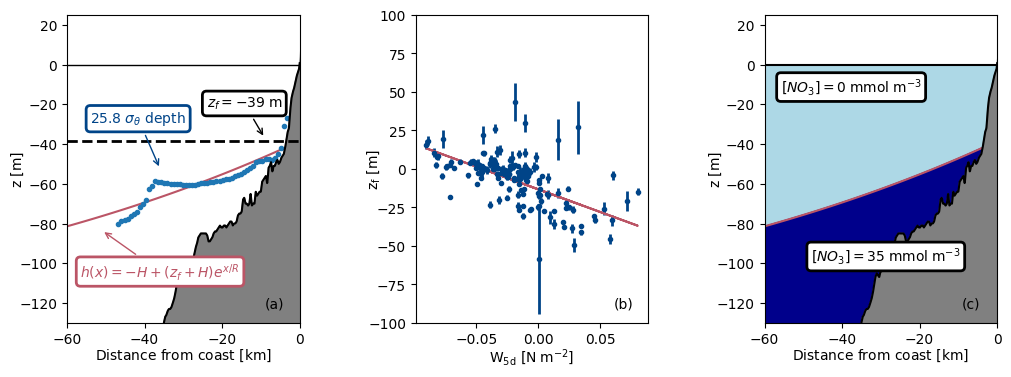

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
plt.subplots_adjust(wspace=0.5)

d = nhl_grid.isel(time=15)
mask = ~np.isnan(d)
axs[0].plot(d["meters"], d["pycno_depth"], ".")
axs[0].plot(
    np.arange(-60, 5),
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values),
    zorder=1,
    c="#BB5566",
)
axs[0].fill_between(meters, -1000, topo, color="grey")
axs[0].plot(meters, topo, color="black")
axs[0].set_ylim([-130, 25])
axs[0].set_xlim([-60, 0])
axs[0].set_xlabel("Distance from coast [$\\mathsf{km}$]", labelpad=0)
axs[0].set_ylabel("z [$\\mathsf{{m}}$]", labelpad=-5)
axs[0].minorticks_off()
bbox = {"boxstyle": "round", "fc": "w", "ec": "#BB5566", "lw": 2}
axs[0].annotate(
    "$h(x)=-H+(z_f+H)e^{x/R}$",
    xy=(0.15, 0.3),
    xytext=(0.4, 0.15),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "#BB5566"},
    color="#BB5566",
    ha="center",
)
axs[0].axhline(d.Zf, ls="--", color="k", linewidth=2)
axs[0].axhline(0, color="k", linewidth=1)
bbox = {"boxstyle": "round", "fc": "w", "ec": "k", "lw": 2}
axs[0].annotate(
    f"$z_f={d.Zf.values:.0f} \\; \\mathsf{{m}}$",
    xy=(0.85, 0.6),
    xytext=(0.6, 0.7),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "k"},
    color="k",
)
bbox = {"boxstyle": "round", "fc": "w", "ec": "#004488", "lw": 2}
axs[0].annotate(
    "25.8 $\\sigma_{\\theta}$ depth",
    xy=(0.4, 0.5),
    xytext=(0.1, 0.65),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "#004488"},
    color="#004488",
)


# compare results below for rough estimates from AB 2002: a~=-0.85,b~=-23
mask = (~np.isnan(nhl_al_wind.Zf)) & (~np.isnan(wind_al_nhl[wind_use])) & (m >= 4) & (m <= 9) & (fit_rmse < 10)
axs[1].errorbar(
    wind_al_nhl[wind_use][mask],
    nhl_al_wind["Zf"][mask],
    nhl_al_wind["Zf_err"][mask],
    linestyle="",
    marker=".",
    elinewidth=2,
    color="#004488",
)
axs[1].plot(
    wind_al_nhl[wind_use][mask],
    wind_al_nhl[wind_use][mask] * fit[0] + fit[1],
    label=f"$\\beta_0$={fit[1]:.2f}\n$\\beta_1$={fit[0]:.2f}",
    color="#BB5566",
)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{N \\; m^{-2}}$]", labelpad=0)
axs[1].set_ylabel("$\\mathsf{z_f}$ [$\\mathsf{m}$]", labelpad=-10)
axs[1].minorticks_off()
bbox = {"boxstyle": "round", "fc": "w"}

d = nhl_grid.isel(time=15)
mask = ~np.isnan(d)
axs[2].fill_between(
    np.arange(-60, 5)[pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0],
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values)[
        pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0
    ],  # ty:ignore[not-subscriptable]; this is ugly and probably should be fixed, but okay for now
    0,
    color="lightblue",
)
axs[2].fill_between(
    np.arange(-60, 5)[pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0],
    -1000,
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values)[
        pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0
    ],  # ty:ignore[not-subscriptable]; this is ugly and probably should be fixed, but okay for now
    color="darkblue",
)
axs[2].fill_between(
    np.arange(-60, 5)[pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) >= -1],
    -1000,
    0,
    color="darkblue",
)
axs[2].plot(
    np.arange(-60, 5),
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values),
    zorder=1,
    c="#BB5566",
)
axs[2].fill_between(meters, -1000, topo, color="grey")
axs[2].plot(meters, topo, color="black")
axs[2].axhline(0, c="k")
axs[2].set_ylim([-130, 25])
axs[2].set_xlim([-60, 0])
axs[2].set_xlabel("Distance from coast [$\\mathsf{km}$]", labelpad=0)
axs[2].set_ylabel("z [$\\mathsf{{m}}$]", labelpad=-5)
axs[2].minorticks_off()
bbox = {"boxstyle": "round", "fc": "w", "ec": "k", "lw": 2}
axs[2].annotate(
    "$[NO_3]=0 \\; \\mathsf{mmol \\; m^{-3}}$",
    xy=(0.07, 0.75),
    xytext=(0.07, 0.75),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "k"},
    color="k",
)
bbox = {"boxstyle": "round", "fc": "w", "ec": "k", "lw": 2}
axs[2].annotate(
    "$[NO_3]=35 \\; \\mathsf{mmol \\; m^{-3}}$",
    xy=(0.2, 0.2),
    xytext=(0.2, 0.2),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "k"},
    color="k",
)


axs[0].annotate("(a)", xy=(0.85, 0.05), xycoords="axes fraction", fontsize=10)
axs[1].annotate("(b)", xy=(0.85, 0.05), xycoords="axes fraction", fontsize=10)
axs[2].annotate("(c)", xy=(0.85, 0.05), xycoords="axes fraction", fontsize=10)

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/simple-model.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    dpi=600,
    bbox_inches="tight",
)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.589
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     1065.
Date:                Mon, 12 Jan 2026   Prob (F-statistic):          1.41e-145
Time:                        19:56:31   Log-Likelihood:                -2327.2
No. Observations:                 744   AIC:                             4658.
Df Residuals:                     742   BIC:                             4668.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9948      0.350     19.973      0.000       6.307       7.682
x1             0.6109      0.019     32.638      0.000       0.574       0.648
==============================================================================
Omnibus:                       12.133   Durbin-Watson:                   0.496
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               12.533
Skew:                           0.316   Prob(JB):                      0.00190
Kurtosis:                       2.927   Cond. No.                         32.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

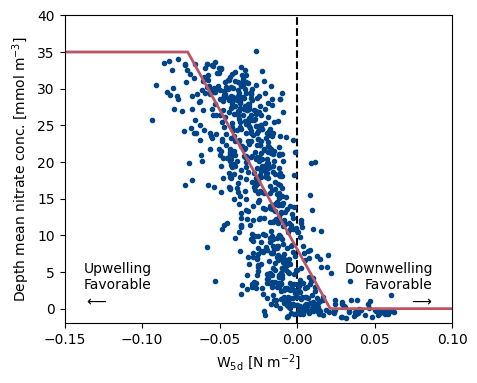

In [14]:
wind_al_nitrate, nitrate_al_wind = xr.align(wind, inner_nitrate)
slope = 1 / fit[0]
intercept = -fit[1] / fit[0]

fig, ax = plt.subplots(figsize=(5, 4))
ax.axvline(0, ls="--", color="black")
ax.plot(
    wind_al_nitrate[wind_use],
    nitrate_al_wind["nitrate"].mean(dim="depth", skipna=True),
    ".",
    color="#004488",
)
ax.set_xlim(-0.15, 0.1)
ax.set_ylim(-2, 40)
ax.set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{N \\; m^{-2}}$]")
ax.set_ylabel("Depth mean nitrate conc. $[\\mathsf{mmol \\; m^{-3}}]$")
ax.plot(slope * zf + intercept, mod_nda, color="#BB5566", linewidth=2)
ax.text(
    0.05,
    0.06,
    "Upwelling\nFavorable\n$\\longleftarrow$",
    transform=ax.transAxes,
    fontsize=10,
)
ax.text(
    0.95,
    0.06,
    "Downwelling\nFavorable\n$\\longrightarrow$",
    transform=ax.transAxes,
    fontsize=10,
    ha="right",
)

# computing r^2 between fit and data
xp = slope * zf + intercept
xp_idx = xp.argsort()
xp = xp[xp_idx]
mod_nda_idx = mod_nda[xp_idx]
mod_nda_interp = np.interp(wind_al_nitrate[wind_use], xp, mod_nda_idx)
mask = ~np.isnan(mod_nda_interp) & ~np.isnan(
    nitrate_al_wind["nitrate"].mean(dim="depth", skipna=True),
)
ols_fit = sm.OLS(
    mod_nda_interp[mask],
    sm.add_constant(
        (nitrate_al_wind["nitrate"].mean(dim="depth", skipna=True)[mask]).values,
    ),
).fit()
bbox = {"boxstyle": "round", "fc": "w"}

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/nitrate-wind.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    bbox_inches="tight",
    dpi=600,
)

ols_fit.summary()

In [15]:
tdelay = np.arange(1, 21)
wkd_correlation_zf = np.nan * np.zeros(tdelay.shape)
for i, t in enumerate(tqdm(tdelay)):
    fout = np.nan * np.zeros(len(wind["day_num"]))
    for j, _f in enumerate(fout):
        temp = ws_integrand(
            wind["day_num"].values[j - t * 5 : j],
            wind["day_num"].values[j],
            wind["coare_y"].values[j - t * 5 : j],
            t,
            rho=1,
        )
        mask = ~np.isnan(temp)
        if not np.any(np.isnan(wind.coare_y[j - t * 5 : j])) and temp.size != 0:
            fout[j] = simpson(temp[mask], x=wind["day_num"].values[j - t * 5 : j][mask]) / t
    temp = xr.Dataset(
        data_vars={"wkd": (["time"], fout)},
        coords={"time": wind["time"]},
    )
    temp_wind, temp_nhl = xr.align(temp, nhl_grid)
    m = dt2cal(temp_nhl["time"].values).T[1]
    mask = (temp_nhl["Zf"] < 100) & (temp_nhl["Zf"] > -100)
    summer = (m >= 4) & (m <= 9) & (mask) & (~np.isnan(temp_wind.wkd)) & (~np.isnan(temp_nhl.Zf))
    wkd_correlation_zf[i] = sm.tsa.stattools.ccf(
        temp_wind["wkd"][summer].values,
        temp_nhl["Zf"][summer].values,
        adjusted=True,
        nlags=1,
    )[0]

100%|██████████| 20/20 [02:03<00:00,  6.16s/it]


In [16]:
tdelay = np.arange(1, 21)
wkd_correlation_n = np.nan * np.zeros(tdelay.size)
for i, t in enumerate(tqdm(tdelay)):
    fout = np.nan * np.zeros(len(wind["day_num"]))
    for j, _f in enumerate(fout):
        temp = ws_integrand(
            wind["day_num"].values[j - t * 5 : j],
            wind["day_num"].values[j],
            wind["coare_y"].values[j - t * 5 : j],
            t,
            rho=1,
        )
        mask = ~np.isnan(temp)
        if not np.any(np.isnan(wind.coare_y[j - t * 5 : j])) and temp.size != 0:
            fout[j] = simpson(temp[mask], x=wind["day_num"].values[j - t * 5 : j][mask]) / t
    temp = xr.Dataset(
        data_vars={"wkd": (["time"], fout)},
        coords={"time": wind["time"]},
    )
    temp_nitrate, temp_wind = xr.align(
        inner_nitrate["depth_integrated_nitrate"],
        temp["wkd"],
    )
    m = dt2cal(temp_wind["time"].values).T[1]
    mask = ~np.isnan(temp_nitrate) & ~np.isnan(temp_wind)
    summer = (m >= 4) & (m <= 9) & (mask)
    wkd_correlation_n[i - 1] = sm.tsa.stattools.ccf(
        temp_nitrate[summer].values,
        temp_wind[summer].values,
        adjusted=True,
        nlags=1,
    )[0]

100%|██████████| 20/20 [02:02<00:00,  6.11s/it]


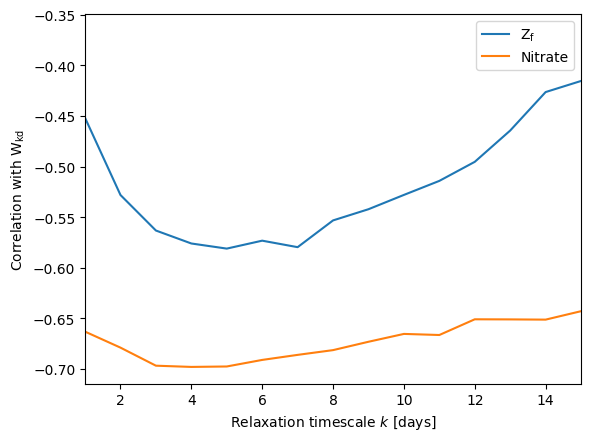

In [17]:
fig, ax = plt.subplots()
ax.plot(tdelay, wkd_correlation_zf, label="$\\mathsf{Z_f}$")
ax.plot(tdelay, wkd_correlation_n, label="Nitrate")
ax.set_xlabel("Relaxation timescale $k$ [$\\mathsf{days}$]")
ax.set_ylabel("Correlation with $\\mathsf{W_{kd}}$")
ax.legend()
ax.set_xlim(1, 15)
ax.minorticks_off()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.447
Model:                            WLS   Adj. R-squared:                  0.444
Method:                 Least Squares   F-statistic:                     152.0
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           5.63e-26
Time:                        20:00:37   Log-Likelihood:                -758.92
No. Observations:                 190   AIC:                             1522.
Df Residuals:                     188   BIC:                             1528.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -14.5906      0.811    -17.997      0.000     -16.190     -12.991
x1          -308.6045     25.033    -12.328      0.000    -357.986    -259.223
==============================================================================
Omnibus:                       19.850   Durbin-Watson:                   1.527
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               24.005
Skew:                          -0.721   Prob(JB):                     6.13e-06
Kurtosis:                       3.976   Cond. No.                         39.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

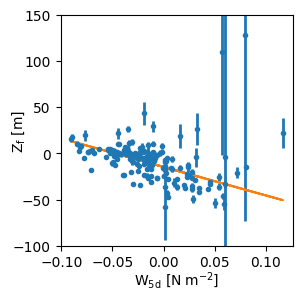

In [18]:
wind_use = "w5d"
wind_al_nhl, nhl_al_wind = xr.align(wind, nhl_grid)
m = dt2cal(nhl_al_wind["time"].values).T[1]
mask = (~np.isnan(nhl_al_wind.Zf)) & (~np.isnan(wind_al_nhl[wind_use]))
wls_fit = sm.WLS(
    nhl_al_wind["Zf"][mask].values,
    sm.add_constant(wind_al_nhl[wind_use][mask].values),
    1 / (nhl_al_wind["Zf_err"][mask].values ** 2),
    missing="drop",
).fit()
fit = wls_fit.params[::-1]
r_squared = wls_fit.rsquared

fig, ax = plt.subplots(figsize=(3, 3))
ax.errorbar(
    wind_al_nhl[wind_use][mask],
    nhl_al_wind["Zf"][mask],
    nhl_al_wind["Zf_err"][mask],
    linestyle="",
    marker=".",
    elinewidth=2,
)
ax.plot(
    wind_al_nhl[wind_use][mask],
    wind_al_nhl[wind_use][mask] * fit[0] + fit[1],
    label=f"$\\beta_0$={fit[1]:.2f}\n$\\beta_1$={fit[0]:.2f}",
)
ax.set_ylim(-100, 150)
ax.set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{N \\; m^{-2}}$]", labelpad=0)
ax.set_ylabel("$\\mathsf{Z_f}$ [$\\mathsf{m}$]", labelpad=-10)
bbox = {"boxstyle": "round", "fc": "w"}
wls_fit.summary()

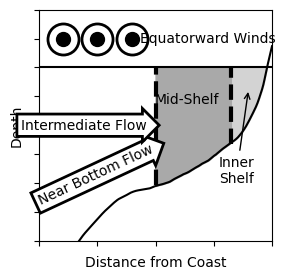

In [19]:
topo_smoothed = savgol_filter(topo, 100, 1)
plt.figure(figsize=(3, 3))
plt.plot(meters, topo_smoothed, "-", label="s=0", c="k")
plt.xlim(-40, 0)
plt.ylim(-120, 40)
plt.minorticks_off()
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])
bbox = {"boxstyle": "rarrow,pad=0.3", "fc": "w", "ec": "k", "lw": 2}
plt.annotate(
    "Near Bottom Flow",
    xy=(-20, -95),
    fontsize=10,
    bbox=bbox,
    color="k",
    rotation=25,
    ha="right",
)
plt.annotate(
    "Intermediate Flow",
    xy=(-21.5, -40),
    fontsize=10,
    bbox=bbox,
    color="k",
    rotation=0,
    ha="right",
    va="center",
)
plt.annotate(
    "Inner\nShelf",
    xy=(-4, -15),
    xytext=(-6, -80),
    fontsize=10,
    bbox=None,
    color="k",
    rotation=0,
    ha="center",
    arrowprops={"arrowstyle": "->", "color": "k"},
)
plt.annotate(
    "Mid-Shelf",
    xy=(-9, -25),
    fontsize=10,
    bbox=None,
    color="k",
    rotation=0,
    ha="right",
)
bbox = {"boxstyle": "larrow,pad=0.3", "fc": "w", "ec": "k", "lw": 2}
# plt.annotate(
#     'Ekman Transport',
#     xy=(-29.5, -12),
#     fontsize=10,
#     bbox=bbox,
#     color='k',
#     rotation=0,
#     ha='center',
# )
plt.axhline(0, color="k")
# plt.axhline(0, color='k')
# plt.axvline(-20, -color='k')
plt.fill_between(
    meters[(meters > -7) & (topo_smoothed < 0)],
    topo_smoothed[(meters > -7) & (topo_smoothed < 0)],
    0,
    color="lightgrey",
)
plt.fill_between(
    meters[(meters > -20) & (meters < -7) & (topo_smoothed < 0)],
    topo_smoothed[(meters > -20) & (meters < -7) & (topo_smoothed < 0)],
    0,
    color="darkgrey",
)
plt.xlabel("Distance from Coast")
plt.ylabel("Depth")
# plt.gca().set_aspect(1)
plt.scatter(
    [-24, -30, -36],
    [20, 20, 20],
    s=500,
    edgecolors="black",
    c="white",
    linewidths=2,
)
plt.scatter([-24, -30, -36], [20, 20, 20], s=100, c="black")
plt.annotate(
    "Equatorward Winds",
    xy=(-11, 20),
    fontsize=10,
    color="k",
    rotation=0,
    ha="center",
    va="center",
)
plt.axvline(-7, 0.42, 0.75, c="k", ls="--", lw=3)
plt.axvline(-20, 0.24, 0.75, c="k", ls="--", lw=3)
# plt.scatter([-20], [20], s=[100])
# plt.savefig(
#     os.path.join(notebook_dir, "../manuscript/2d-upwelling-schematic.pdf"), format="pdf"
# )